# Gene Expression Peak-Trough analysis using Polar Plots

April 8, 2024

Analyze the chromatin at genes during peak and trough gene expression.

In [9]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

# Compute replication profile for each gene

For each gene
1. Compute the raw replication profile
2. Compute its replication time (early/late)
3. Will need to normalize by the replicate's S phase
4. Compute the correlation with its gene expression


In [13]:
# mnase_analysis = MNaseOriginAnalysis()

# replicate = 1
# chromosome = 1
# mnase_analysis.load_mnase_data(replicate, chromosome)
# mnase_analysis.compute_sliding_window_counts_all_times()
# mnase_analysis.normalize_samples()

In [3]:
mnase_analysis = MNaseOriginAnalysis()

In [4]:
replicate = 1
chromosome = 10
mnase_analysis.load_mnase_data(replicate, chromosome)

In [5]:
mnase_analysis.compute_sliding_window_counts_all_times()
mnase_analysis.normalize_samples()

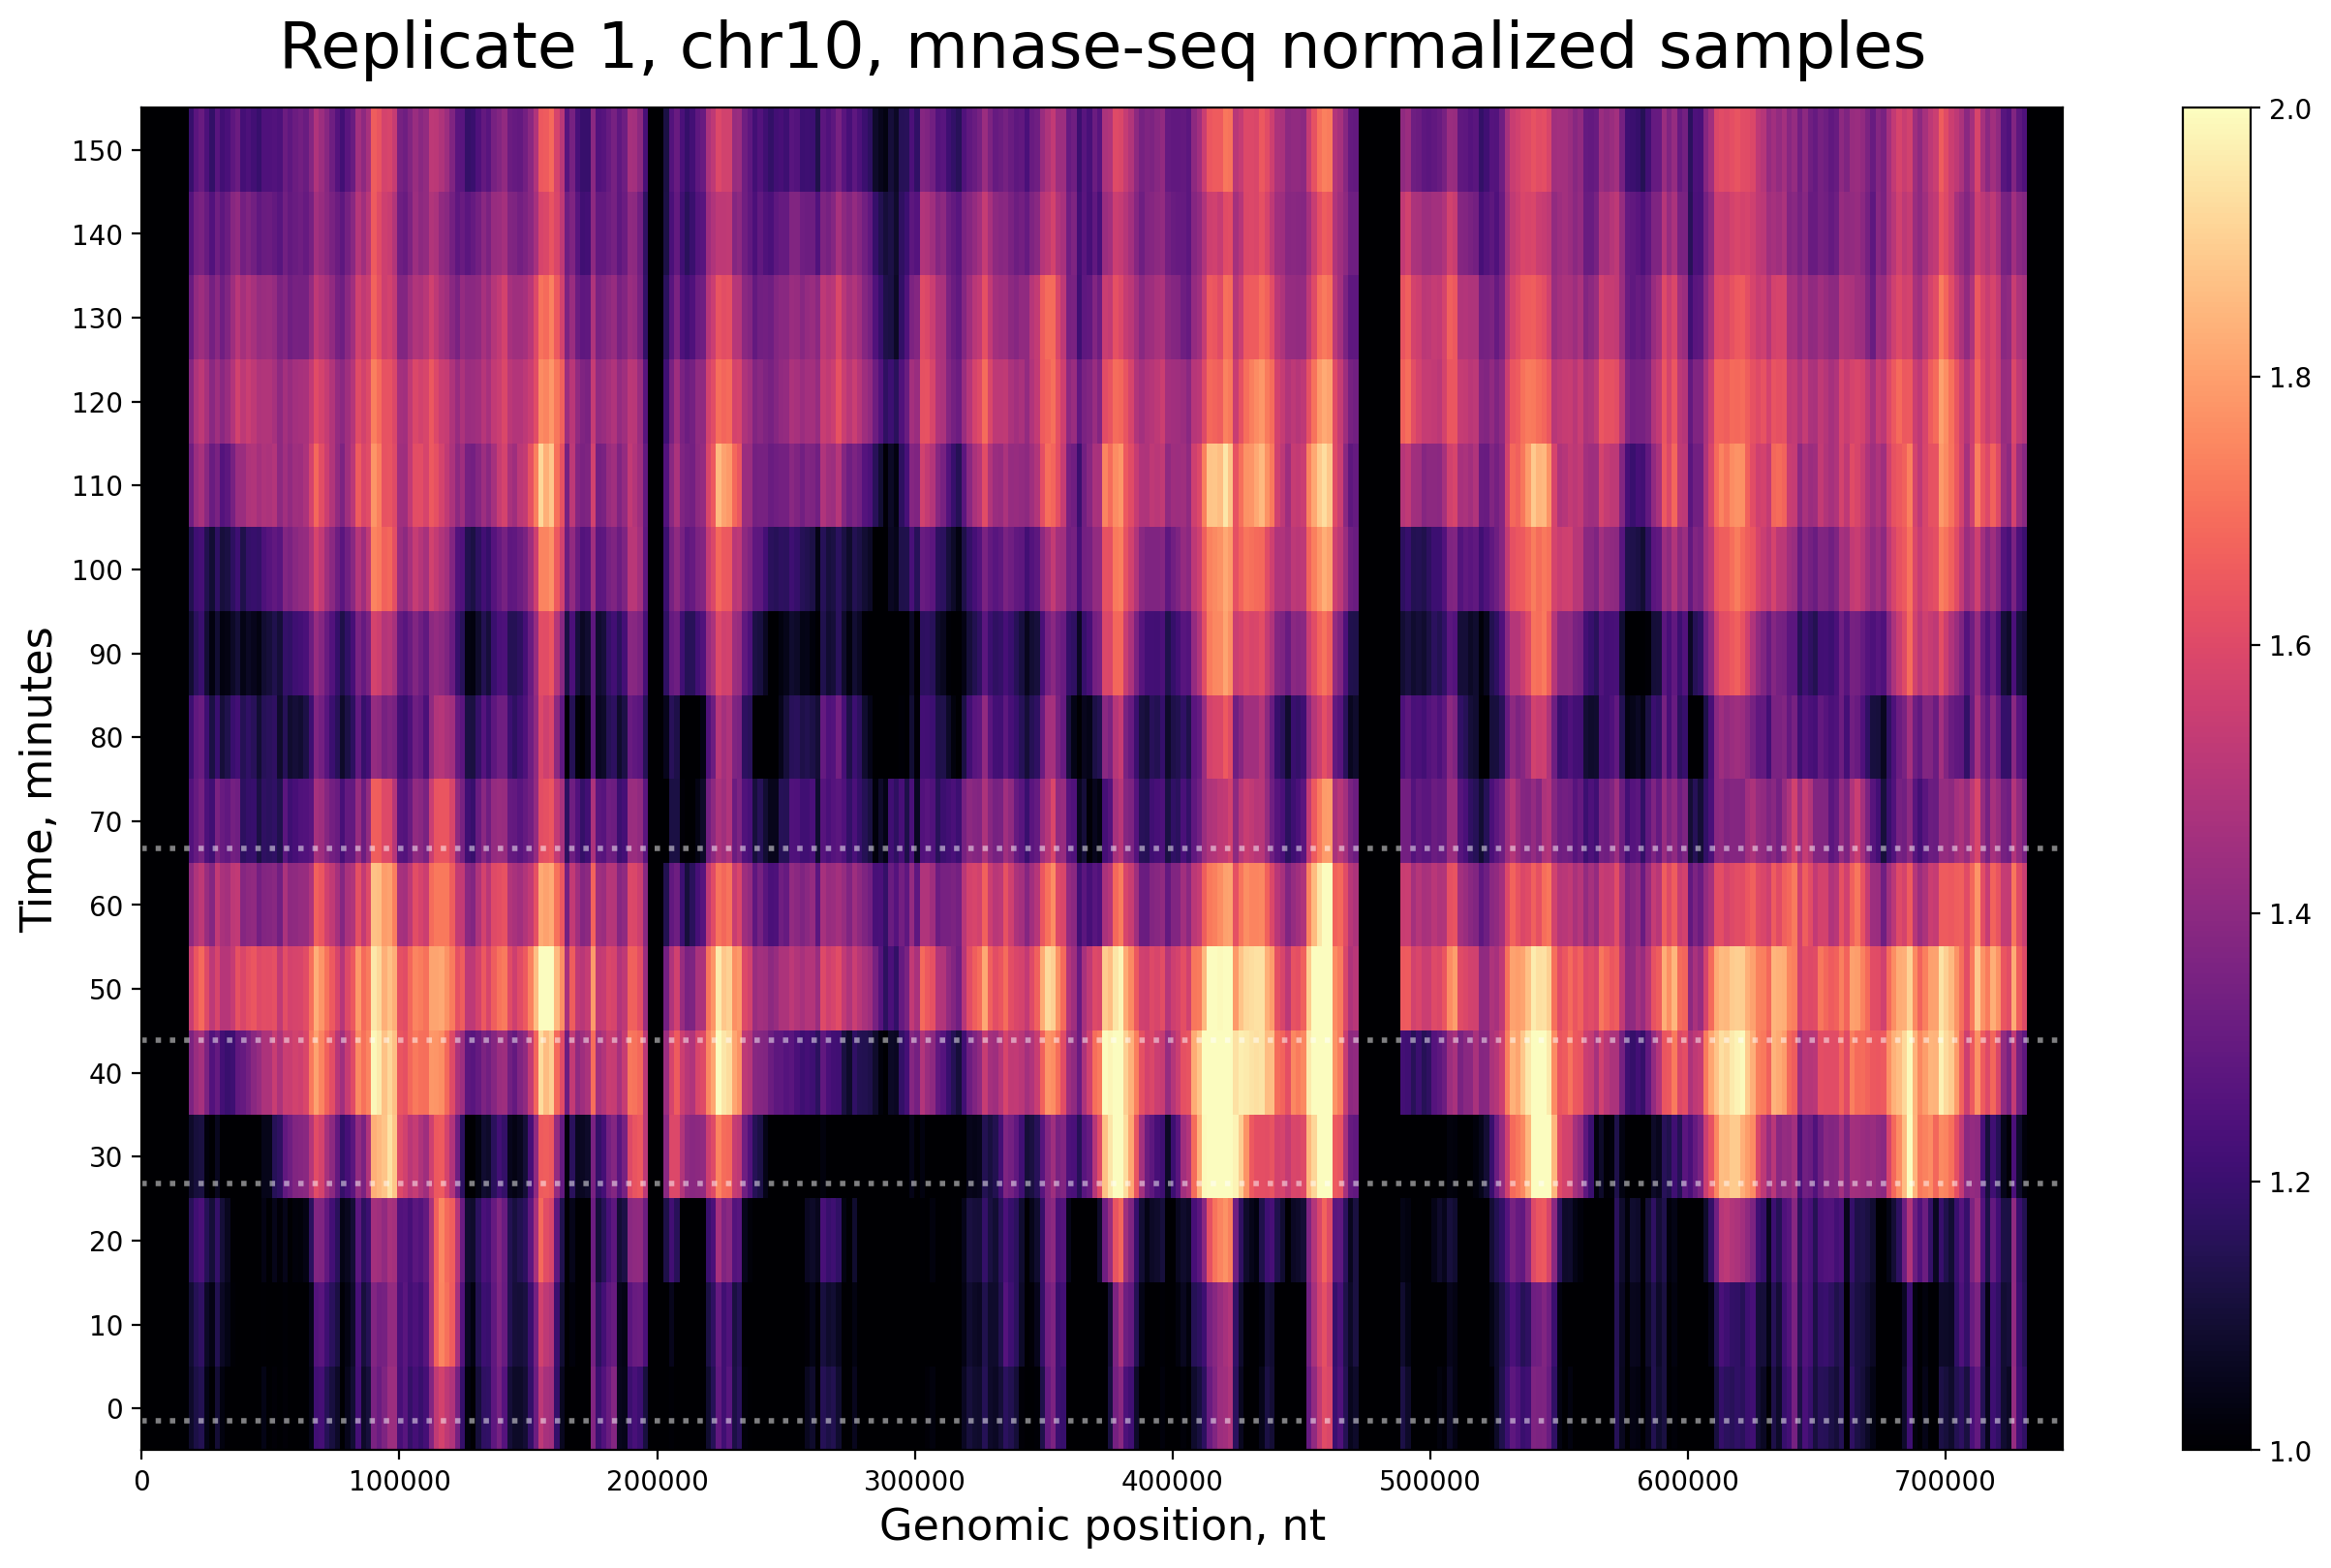

In [6]:
mnase_analysis.plot_heatmap(plot_norm_by_copy=True)

In [7]:
mnase_analysis.compute_sliding_window_counts_all_times()
mnase_analysis.normalize_samples()

AttributeError: 'MNaseOriginAnalysis' object has no attribute 'all_window_counts_nonzero_unhandled'

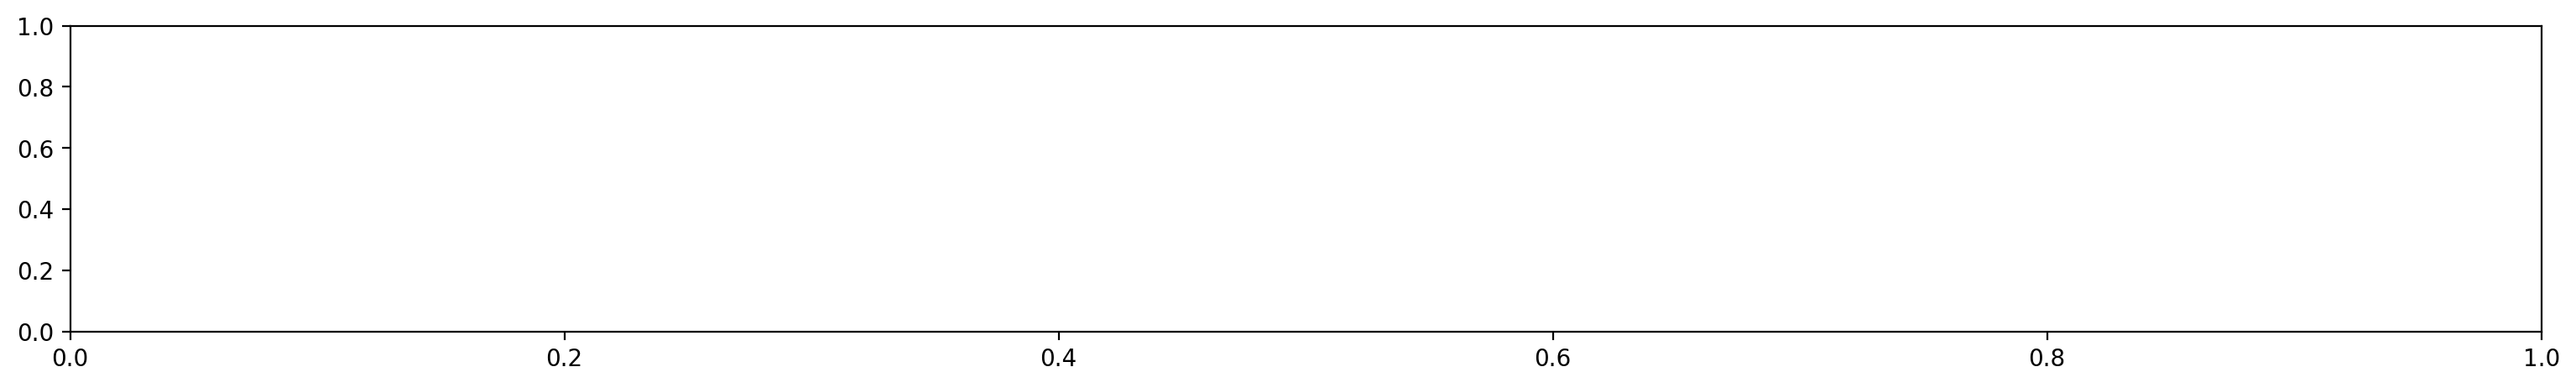

In [8]:
mnase_analysis.plot_bin_normalization_procedure()

In [14]:
# bin_curves_rep1, exp_cor1 = mnase_analysis.compute_bin_curves_and_expression_correlations(replicate=1)

In [15]:
# bin_curves_rep2, exp_cor2 = mnase_analysis.compute_bin_curves_and_expression_correlations(replicate=2)

In [17]:
# plt.figure(figsize=(14, 3))
# plt.subplots_adjust(wspace=0.5)

# plt.subplot(1, 3, 1)
# plt.hist(exp_cor1.values, bins=60)
# plt.title("Distribution of gene expression and\n10k bin correlation\nfor Replicate 1")
# plt.xlabel("Correlation")
# plt.ylabel("Frequency")

# plt.subplot(1, 3, 2)
# plt.hist(exp_cor2.values, bins=60)
# plt.title("Distribution of gene expression and\n10k bin correlation\nfor Replicate 2")
# plt.xlabel("Correlation")
# plt.ylabel("Frequency")

# plt.subplot(1, 3, 3)
# plt.scatter(exp_cor1, exp_cor2, alpha=0.15)
# plt.xlim(-1, 1)
# plt.ylim(-1, 1)
# plt.title("Replicate 1 vs Replicate 2 correlation")
# plt.xlabel("Correlation, Replicate 1")
# plt.ylabel("Correlation, Replicate 2")


# Polar Plot

Goal: Classify genes by their peak and trough gene expression
    
Separately for Mother and Daughter Cells

Output:
1. Time and phase of peak gene expression
2. Time and phase of trough gene expression


In [18]:
from src.gene_expression_deconv_analysis import GeneExpressionAnalysis

ge_analysis = GeneExpressionAnalysis(
    'output/deconvolve_combined_g_opt_2024_03_14/gene_expression/')
ge_analysis.load_gene_expression_fs()

In [ ]:
#ge_analysis.ptrs_ret_df.to_csv('output/gene_expression_ptrs_with_tps_combined_model_2024_04_05.csv')


In [ ]:
from src.peak_to_trough import compute_ptr

In [ ]:
from src.timer import Timer

timer = Timer()
ge_analysis.compute_ptr_inds_tps()
timer.print_time()


In [ ]:
selected_genes = ['DSE1', 'DSE2', 'DSE3', 'DSE4']

In [ ]:
ge_analysis.plot_scatter_polar(selected_genes=selected_genes)

In [ ]:
# Let's create a box plot of the ptr values for each peak phase

def get_quantile_values(ge_analysis, phases):
    ptrs_ret_df = ge_analysis.ptrs_ret_df
    values = ptrs_ret_df[ptrs_ret_df['phase'].isin(phases)].ptr.values
    q25, med, q75 = tuple(np.quantile(values, [0.25, 0.5, 0.75]))
    
    iqr = q75 - q25
    
    lower_whisker_end = q25-iqr*1.5
    upper_whisker_end = q75+iqr*1.5    
    
    lower_whisker = values[values > lower_whisker_end].min()
    upper_whisker = values[values < upper_whisker_end].max()
    
    return lower_whisker, q25, med, q75, upper_whisker, iqr, len(values)


In [ ]:
cg1_qs = get_quantile_values(ge_analysis, ['C_G1'])
dg1_qs = get_quantile_values(ge_analysis, ['D_G1'])
s_qs = get_quantile_values(ge_analysis, ['D_S', 'C_S'])
g2m_qs = get_quantile_values(ge_analysis, ['D_G2M', 'C_G2M'])

ptr_qs_dat = np.stack([cg1_qs, dg1_qs, s_qs, g2m_qs])
ptr_phase_qs_df = pd.DataFrame(ptr_qs_dat, index=['CG1', 'DG1', 'S', 'G2M'],
            columns=['lower_whisker', 'q25', 'median', 'q75', 'upper_whisker',
                     'iqr', 'n'])


In [ ]:
ptr_phase_qs_df['plot_index'] = np.arange(len(ptr_phase_qs_df))

In [ ]:
ptr_phase_qs_df

In [ ]:
from src.model import color_for_key
plt.figure(figsize=(4, 2))

for idx, row in ptr_phase_qs_df.iterrows():
    color = color_for_key(idx)
    plt.plot([row.plot_index, row.plot_index],
             [row['q25'], row['q75']], lw=10, solid_capstyle='butt', zorder=1, c=color)
    plt.plot([row.plot_index, row.plot_index],
            [row['lower_whisker'], row['upper_whisker']], lw=1, solid_capstyle='butt', zorder=1, c=color)
    plt.scatter(row.plot_index, row['median'], c='black', zorder=10, s=20, marker='D')
    
    
xtick_names = [f"{ptr_phase_qs_df.index.values[i]}\nn={ptr_phase_qs_df.n.values[i]:.0f}" 
               for i in range(len(ptr_phase_qs_df))]

plt.xticks(ptr_phase_qs_df.plot_index, xtick_names)
plt.title("PTR values per phase")

plt.yticks(np.arange(0.9, 1.2, 0.05))
plt.ylim(0.95, 1.2)


In [ ]:
thresholded_ptrs, format_str, phase_counts = ge_analysis.threshold_ptrs(1.)

In [ ]:
plt.figure(figsize=(4, 2))
plt.hist(ge_analysis.ptrs_ret_df.ptr, bins=100, color='gray')
plt.axvline(ge_analysis.ptr_threshold, c='red')
plt.xlim(1, 2)
0
plt.yscale('log')
plt.title("Distribution of deconvolved\ngene expression PTRs")

In [ ]:
plotting_ptrs = ge_analysis.plot_scatter_polar_full(selected_genes=selected_genes)
plt.title("Gene expression PTR per cell-cycle phase", pad=10)

In [ ]:
phase_counts_df = pd.DataFrame(phase_counts, index=['counts']).T
phase_counts_df = phase_counts_df.sort_index()
phase_counts_df

In [ ]:
from src.model import color_for_key

plt.figure(figsize=(6, 3))
plt.bar(phase_counts_df.index, phase_counts_df['counts'], 
        color=[
            color_for_key('CG1'),
            color_for_key('DG1'),
            color_for_key('G2M'),
            color_for_key('S'),
        ])

plt.title(f"Gene counts with PTR > threshold: {ge_analysis.ptr_threshold}", pad=10)


In [ ]:
import glob 
from src.combined_chromatin_model import CombinedChromatinModel, \
    load_chromatin_model_from_disk

def get_ge_peak_trough_chrom_f(ge_analysis, orf_name):
    """From the gene expression analysis, get the peak and trough gene expression 
    points in the time series and plot how the chromatin looks for the given orf
    
    todo: create an analysis that allows us to aggregate sets of orf names.
    Plot examples from the set and an aggregate of the peak and trough images.
    """

    gene = ge_analysis.geneset.loc[orf_name]
    gene_ptr_row = ge_analysis.ptrs_ret_df.loc[orf_name]

    # We need the peak and trough timepoint indices
    peak_idx, trough_idx = gene_ptr_row.peak_index.astype(int), \
        gene_ptr_row.trough_index.astype(int)

    # load the gene chromatin images F)
    chromatin_dir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'

    # todo: hard-coded as fixed image shape, move to global config
    image_shape = 8, 25
    
    f = load_chromatin_model_from_disk(orf_name, chromatin_dir, f_only=True)
    f_imgs = f.reshape((-1, *image_shape))
    
    return f_imgs[peak_idx], f_imgs[trough_idx]


In [ ]:
sorted_thresh_ptr_genes = thresholded_ptrs.sort_values('ptr', ascending=False)
sorted_thresh_ptr_genes.head()

In [ ]:
# Get the aggregate peaks and trough images for a set of genes
# to observe the chromatin differences between peaks and troughs of 
# the expressed gene set

def retrieve_selected_aggreagate_fs_for_ptr_set(ge_analysis, selected_orf_names):

    strands = ge_analysis.geneset.loc[selected_orf_names].strand

    selected_peak_fs = None
    selected_trough_fs = None

    k = len(selected_orf_names)

    for i in range(k):
        orf_name = selected_orf_names[i]

        try: 
            peak_f, trough_f = get_ge_peak_trough_chrom_f(ge_analysis, orf_name)
        except IndexError:
            print(f"No f file for: {orf_name}. Skipping")
            continue

        strand = strands.loc[orf_name]

        if strand == '-':
            peak_f = np.fliplr(peak_f)
            trough_f = np.fliplr(trough_f)

        if selected_peak_fs is None:
            aggregate_peaks = np.zeros_like(peak_f)
            aggregate_troughs = np.zeros_like(trough_f)

            selected_peak_fs = np.zeros((k, *peak_f.shape))
            selected_trough_fs = np.zeros((k, *peak_f.shape))

        selected_peak_fs[i] = peak_f
        selected_trough_fs[i] = trough_f

    aggregate_peaks = selected_peak_fs.mean(axis=0)
    aggregate_troughs = selected_trough_fs.mean(axis=0)
    return aggregate_peaks, aggregate_troughs, selected_peak_fs, selected_trough_fs

In [ ]:
def plot_aggregate(sel_orfs, name):
    (aggregate_peaks, 
     aggregate_troughsroughs, 
     selected_peak_fs, 
     selected_trough_fs) = retrieve_selected_aggreagate_fs_for_ptr_set(ge_analysis, sel_orfs)

    fig, (peak_ax, trough_ax) = plt.subplots(2, 1, figsize=(3.5, 3))
    plt.subplots_adjust(hspace=0.5)

    def plot_im(ax, dat):
        ax.imshow(dat, origin='lower', cmap='magma_r', vmax=30, aspect='auto')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.axvline(9, c='black', lw=1) # todo: hard-coded tss location

    plot_im(peak_ax, aggregate_peaks)
    peak_ax.set_ylabel("Peak")

    plot_im(trough_ax, aggregate_troughs)
    trough_ax.set_ylabel("Trough")

    plt.suptitle(f"Aggregate {name}, n={len(sel_orfs)}")

In [ ]:
# Examine the aggregate plots for the DG1, CG1, G2M, S genes

dg1_ptr_genes = sorted_thresh_ptr_genes[sorted_thresh_ptr_genes['phase'] == 'D_G1']
cg1_ptr_genes = sorted_thresh_ptr_genes[sorted_thresh_ptr_genes['phase'] == 'C_G1']
s_ptr_genes = sorted_thresh_ptr_genes[(sorted_thresh_ptr_genes['phase'] == 'C_S')
                                     | (sorted_thresh_ptr_genes['phase'] == 'D_S')]
g2m_ptr_genes = sorted_thresh_ptr_genes[(sorted_thresh_ptr_genes['phase'] == 'C_G2M')
                                     | (sorted_thresh_ptr_genes['phase'] == 'D_G2M')]

In [ ]:
#plot_aggregate(dg1_ptr_genes.index.values, "Peak DG1")
#plot_aggregate(cg1_ptr_genes.index.values, "Peak CG1")

In [ ]:
# plot_aggregate(s_ptr_genes.index.values, "Peak S")
# plot_aggregate(g2m_ptr_genes.index.values, "Peak G2M")